# Radiative Flux Components

Layer 2b. For a selected surface, plots incident **Earth IR**, **Albedo**, and **Direct Solar** flux [W m⁻²] over one orbit, with per-patch min/max spread.

**Requires:** `outputs/viewfactors.npz`

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from geometry.constants import A_ALB, J_IR, S0
from viewfactor import load_profiles

# -- Paths ------------------------------------------------------------------
VF_NPZ           = Path('outputs/viewfactors.npz')
BODY_ROLES_JSON  = Path('outputs/body_roles.json')

body_roles = json.loads(BODY_ROLES_JSON.read_text(encoding='utf-8'))
# body_roles['+X'] -> surface name for body +X face, etc.

# -- Select surface ---------------------------------------------------------
# Use a body-axis label ('+X', '-Y', '+Z' ...) or a surface name directly.
SURFACE = body_roles['+Y']   # body +X = target-pointing face

In [2]:
profiles, _meta = load_profiles(VF_NPZ)
by_name = {p.surface_name: p for p in profiles}

print(f'  {"body axis":<12}  {"surface name":<20}  in npz')
print(f'  {"-"*12}  {"-"*20}  ------')
for label in sorted(body_roles):
    name = body_roles[label]
    flag = 'yes' if name in by_name else 'NO (re-run viewfactor.ipynb)'
    print(f'  {label:<12}  {name:<20}  {flag}')

  body axis     surface name          in npz
  ------------  --------------------  ------
  +X            bus_+Z                yes
  +Y            bus_+X                yes
  +Z            bus_+Y                yes
  -X            bus_-Z                yes
  -Y            bus_-X                yes
  -Z            bus_-Y                yes


In [3]:
profile = by_name[SURFACE]
u_deg   = np.degrees(profile.u)
eclipse = profile.eclipse

# Compute flux components directly (no solar-panel IR needed)
earth_ir = J_IR   * profile.earth_view
albedo   = A_ALB  * S0 * profile.albedo_view
solar    = S0     * profile.solar_view

print(f'Surface : {SURFACE}')
print(f'Samples : {u_deg.size}')
print(f'Peak Earth IR     : {earth_ir.max():.1f} W/m²')
print(f'Peak Albedo       : {albedo.max():.1f} W/m²')
print(f'Peak Direct Solar : {solar.max():.1f} W/m²')

Surface : bus_+X
Samples : 410
Peak Earth IR     : 107.8 W/m²
Peak Albedo       : 90.9 W/m²
Peak Direct Solar : 0.0 W/m²


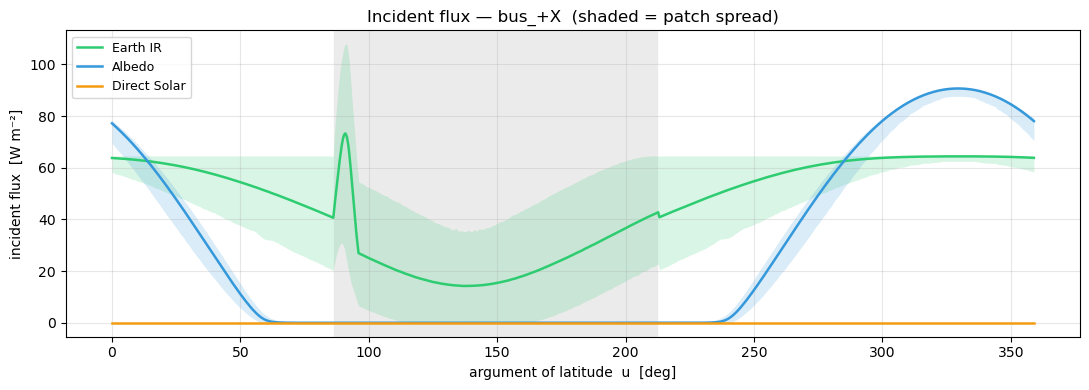

In [4]:
# ── U vs Flux trace ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

for data, label, color in [
    (earth_ir, 'Earth IR',     '#2ecc71'),
    (albedo,   'Albedo',       '#3498db'),
    (solar,    'Direct Solar', '#f39c12'),
]:
    mean = data.mean(axis=(1, 2))
    lo   = data.min(axis=(1, 2))
    hi   = data.max(axis=(1, 2))
    ax.fill_between(u_deg, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(u_deg, mean, lw=1.8, color=color, label=label)

# eclipse shading
edges = np.empty(u_deg.size + 1)
edges[1:-1] = 0.5 * (u_deg[:-1] + u_deg[1:])
edges[0]  = u_deg[0]  - 0.5 * (u_deg[1]  - u_deg[0])
edges[-1] = u_deg[-1] + 0.5 * (u_deg[-1] - u_deg[-2])
run = None
for i, e in enumerate(eclipse):
    if e and run is None:    run = i
    elif not e and run is not None:
        ax.axvspan(edges[run], edges[i], color='0.92', zorder=0)
        run = None
if run is not None:
    ax.axvspan(edges[run], edges[-1], color='0.92', zorder=0)

ax.set_xlabel('argument of latitude  u  [deg]')
ax.set_ylabel('incident flux  [W m⁻²]')
ax.set_title(f'Incident flux — {SURFACE}  (shaded = patch spread)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()